In [109]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

def trans_vel_roms(u,v,angle):
    # np.cos(angle*np.pi/180)
    # np.sin(angle*np.pi/180)
    u_east=u*np.cos(angle*np.pi/180)-v*np.sin(angle*np.pi/180)
    v_north=u*np.sin(angle*np.pi/180)+v*np.cos(angle*np.pi/180)
    return u_east,v_north

from scipy.interpolate import griddata

def griddata_matlab(lona,lata,ugos,lon_rho,lat_rho):
    points = np.column_stack((lona.ravel(), lata.ravel()))
    values = ugos.ravel()
    
    # 步骤2: 创建目标网格点
    target_points = np.column_stack((lon_rho.ravel(), lat_rho.ravel()))
    
    # 步骤3: 执行插值
    ugos_interp = griddata(points, values, target_points, method='linear')
    
    # 步骤4: 重塑为原始网格形状
    ugos_interp = ugos_interp.reshape(lon_rho.shape)
    return ugos_interp

def snake_scan(matrix):
    """
    ravel() for particles
    matrix: 
        
    flat_array: 1d arrays
    """
    rows, cols = matrix.shape
    result = []
    
    for i in range(rows):
        if i % 2 == 0:  # 偶数行：从左到右
            result.extend(matrix[i, :])
        else:           # 奇数行：从右到左
            result.extend(matrix[i, ::-1])
    
    return np.array(result)

import numpy as np
from scipy.interpolate import griddata

def particle_roughdistr_onetime(lonp, latp, cI, cJ, NP, Range, shape='circle'):
    '''    
    para:
        lonp, latp: grid
        cI, cJ: center of region
        NP: numbers of p
        Range: sub region
        shape:  ('box' or 'circle')
    '''
    squareP = int(np.sqrt(NP))
    Len = int(Range)
    
    # 
    if Len % 2 == 0:
        II = [int(cI - Len/2), int(cI + Len/2)]
        JJ = [int(cJ - Len/2), int(cJ + Len/2)]
    else:
        II = [int(cI - (Len+1)/2), int(cI + Len/2)]
        JJ = [int(cJ - (Len+1)/2), int(cJ + Len/2)]
    
    # sub region
    lonp1 = lonp[JJ[0]:JJ[1], II[0]:II[1]]
    latp1 = latp[JJ[0]:JJ[1], II[0]:II[1]]
    
    # 
    Iin, Jin = np.meshgrid(np.arange(lonp1.shape[0]), 
                          np.arange(lonp1.shape[1]))
    
    points = np.column_stack((Iin.ravel(), Jin.ravel()))

    # choose shape
    if shape == 'box':
        # 
        I1 = np.linspace(0, lonp1.shape[0]-1, squareP)
        J1 = np.linspace(0, lonp1.shape[1]-1, squareP)
        I11, J11 = np.meshgrid(I1, J1)
        
        # 
        lonp2 = griddata(points, lonp1.ravel(), (I11, J11), method='linear')
        latp2 = griddata(points, latp1.ravel(), (I11, J11), method='linear')
        return snake_scan(lonp2), snake_scan(latp2)
    
    elif shape == 'circle':

        center_x = lonp1.shape[0] / 2
        center_y = lonp1.shape[1] / 2
        
        radius = min(lonp1.shape[0], lonp1.shape[1]) / 2
        
        r = radius * np.sqrt(np.random.rand(NP))  #
        theta = 2 * np.pi * np.random.rand(NP)
        
        # 
        x = center_x + r * np.cos(theta)
        y = center_y + r * np.sin(theta)
        
        # 
        points_target = np.column_stack((x, y))
        lonp2 = griddata(points, lonp1.ravel(), points_target, method='linear')
        latp2 = griddata(points, latp1.ravel(), points_target, method='linear')
        
        return lonp2, latp2



def generate_release_times_hourly(total_particles, particles_per_hour, start_time=0):
    """
    :
        total_particles: 
        particles_per_hour: 
        start_time: 
    :
        timep2: 
    """
    total_particles = int(total_particles)
    particles_per_hour = int(particles_per_hour)

    hours_needed = int(np.ceil(total_particles / particles_per_hour))

    timep2 = []
    for hour in range(hours_needed):
        particles_this_hour = min(particles_per_hour, total_particles - len(timep2))
        hour_start = start_time + hour * 3600
        timep2.extend([hour_start] * particles_this_hour)
    
    return np.array(timep2)

#########################################LASER way ###################################
def equilateral_triangle_on_circle(x, y, radius):
    angles = np.linspace(0, 2*np.pi, 4)[:-1]  # 0°, 120°, 240°
    vertices = np.zeros((3, 2))
    
    for i, angle in enumerate(angles):
        vertices[i, 0] = x + radius * np.cos(angle)
        vertices[i, 1] = y + radius * np.sin(angle)
    
    return vertices

def get_equilateral_triangle_vertices_from_point(x, y, side_length):

    height = (np.sqrt(3) / 2) * side_length
    
    # 计算三个顶点
    vertices = np.array([
        [x, y],  # 给定点
        [x + side_length/2, y - height],  # 右下顶点
        [x - side_length/2, y - height]    # 左下顶点
    ])
    
    return vertices

def particle_setup(grid_min_x, grid_max_x, grid_min_y, grid_max_y, Nums, a1, a2):
   
    if Nums % 9 != 0:
        raise ValueError('Nums should be a multiple of 9')
    else:
        Nums = Nums // 9
    
    print(f'circle radius = {a1}')
    print(f'triplets length = {a2}')
    

    t = np.linspace(0, 2*np.pi, 1000)
    x = np.cos(2*t) * np.cos(t)
    y = np.cos(2*t) * np.sin(t)
    
    # rot 45 degree
    theta = np.pi / 4
    x_rot = np.cos(theta) * x - np.sin(theta) * y
    y_rot = np.sin(theta) * x + np.cos(theta) * y
    
    # 
    x_min, x_max = np.min(x_rot), np.max(x_rot)
    y_min, y_max = np.min(y_rot), np.max(y_rot)
    
    # 
    scale_x = (grid_max_x - grid_min_x) / (x_max - x_min)
    scale_y = (grid_max_y - grid_min_y) / (y_max - y_min)
    
    # 
    offset_x = (grid_max_x + grid_min_x) / 2 - (x_max + x_min) * scale_x / 2
    offset_y = (grid_max_y + grid_min_y) / 2 - (y_max + y_min) * scale_y / 2
    
    # 
    x_final = scale_x * x_rot + offset_x
    y_final = scale_y * y_rot + offset_y
    
    # 
    t_random = 2 * np.pi * np.random.rand(Nums)
    x_random = np.cos(2*t_random) * np.cos(t_random)
    y_random = np.cos(2*t_random) * np.sin(t_random)
    
    # 
    x_random_rot = np.cos(theta) * x_random - np.sin(theta) * y_random
    y_random_rot = np.sin(theta) * x_random + np.cos(theta) * y_random
    
    # 
    x_random_final = scale_x * x_random_rot + offset_x
    y_random_final = scale_y * y_random_rot + offset_y
    
    # 
    vertices = np.zeros((Nums * 3, 2))
    for ii in range(len(x_random_final)):
        start_idx = ii * 3
        end_idx = start_idx + 3
        vertices[start_idx:end_idx] = equilateral_triangle_on_circle(
            x_random_final[ii], y_random_final[ii], a1
        )
    
    # 
    triplets = np.zeros((Nums * 9, 2))
    for ii in range(len(vertices)):
        start_idx = ii * 3
        end_idx = start_idx + 3
        triplets[start_idx:end_idx] = get_equilateral_triangle_vertices_from_point(
            vertices[ii, 0], vertices[ii, 1], a2
        )
    
    return triplets

def Laser_setup_distr(gridresolution,a1,a2,Nums,grid_min_x,grid_max_x,grid_min_y,grid_max_y,lonp,latp,num_gridpoint):
    # circle radius #1/2 *gridresolution
    # a1=1/2
    print(f'circle radius = a1*gridresolution {a1*gridresolution}')
    # triplets length #1/2 *gridresolution
    # a2=1/4
    print(f'triplets = a2*gridresolution {a2*gridresolution}')

    triplets=particle_setup(grid_min_x,grid_max_x,grid_min_y,grid_max_y,Nums,a1,a2);
    px=triplets[:,0]
    py=triplets[:,1]
    PI,PJ=np.meshgrid(np.arange(1,num_gridpoint+1),np.arange(1,num_gridpoint+1))
    lonp1=griddata_matlab(PI,PJ,lonp,px,py)
    latp1=griddata_matlab(PI,PJ,latp,px,py)
    return lonp1,latp1
import scipy.signal as sig
def spectral_freq(u,v,detr=0,wind=0):
    if detr == 1:
        u = u - np.tile(np.mean(u,axis=0),[u.shape[0],1,1])
        v = v - np.tile(np.mean(v,axis=0),[v.shape[0],1,1])
        u = sig.detrend(u, axis=0, type='linear')
        v = sig.detrend(v, axis=0, type='linear')

    # Windowing
    if wind == 1:
        win = np.tile(np.hanning(u.shape[0])[:, None, None],(1, u.shape[1], u.shape[2]) )
        u=u*win
        v=v*win
    freq = np.fft.fftshift(np.fft.fftfreq(u.shape[0], 1))[int(u.shape[0]/2):]
    uh_result = np.fft.fft(u , axis=0)
    vh_result = np.fft.fft(v , axis=0)
    KE_temporal = 0.5*np.fft.fftshift(np.abs(uh_result)**2, axes=(0,))+np.fft.fftshift(np.abs(vh_result)**2, axes=(0,))
    KE=KE_temporal[int(u.shape[0]/2):,:,:]*8/3 # window corr
    return KE,freq

import scipy.signal as sig
def spectral_freq_lag(u,v,detr=0,wind=0):
    if detr == 1:
        u = u - np.tile(np.mean(u,axis=0),[u.shape[0],1])
        v = v - np.tile(np.mean(v,axis=0),[v.shape[0],1])
        u = sig.detrend(u, axis=0, type='linear')
        v = sig.detrend(v, axis=0, type='linear')

    # Windowing
    if wind == 1:
        win = np.tile(np.hanning(u.shape[0])[:, None],(1, u.shape[1]) )
        u=u*win
        v=v*win
    freq = np.fft.fftshift(np.fft.fftfreq(u.shape[0], 1))[int(u.shape[0]/2):]
    uh_result = np.fft.fft(u , axis=0)
    vh_result = np.fft.fft(v , axis=0)
    KE_temporal = 0.5*np.fft.fftshift(np.abs(uh_result)**2, axes=(0,))+np.fft.fftshift(np.abs(vh_result)**2, axes=(0,))
    KE=KE_temporal[int(u.shape[0]/2):,:]*8/3 # window corr
    return KE,freq

def filter_particles(ue,time1,time2):
    ue_subset = ue[:, time1:time2]
    has_nan = np.isnan(ue_subset).any(axis=1)
    clean_indices = ~has_nan
    ue_clean = ue[clean_indices, time1:time2]
    return ue_clean



# check HF Eul and Lag spec 2km

In [83]:
data_dir='/meddy/simingzhang/Data/RB_iceland_data/'
fname='iceland_wave/z_niskin2km_his_hf_depth_500m_grd.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
files=data_dir+fname
print(files)
ds=xr.open_dataset(files)
ds

grid=xr.open_dataset(data_dir+'niskin2km_500m_grd.nc')
dx=1/grid['pm'].values
dy=1/grid['pn'].values
latr=grid['lat_rho'].values

xscale=np.mean([dx,dy])
R=xscale*287
u_eul=u2rho_3d(np.squeeze(ds['u'].values))
v_eul=v2rho_3d(np.squeeze(ds['v'].values))
time1=0
time2=12*24
KE_eul,freq_eul=spectral_freq(u_eul[time1:time2,:,:],v_eul[time1:time2,:,:],detr=1,wind=1)

/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/z_niskin2km_his_hf_depth_500m_grd.0002.nc


In [80]:
data_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/'
pname='wave_pars_P1089T89.5days.nc'
ds=xr.open_dataset(f'{data_dir}{pname}')
ue=ds['ue'].values
ve=ds['ve'].values
ue1=filter_particles(ue,time1,time2)
ve1=filter_particles(ve,time1,time2)
KE_lag,freq_lag=spectral_freq_lag(ue1.T,ve1.T,detr=1,wind=1)

In [95]:
KE_lag.shape
f_freq=4*np.pi*np.sin(np.pi*latr/180)*366.25/(24*3600*365.25)*3600


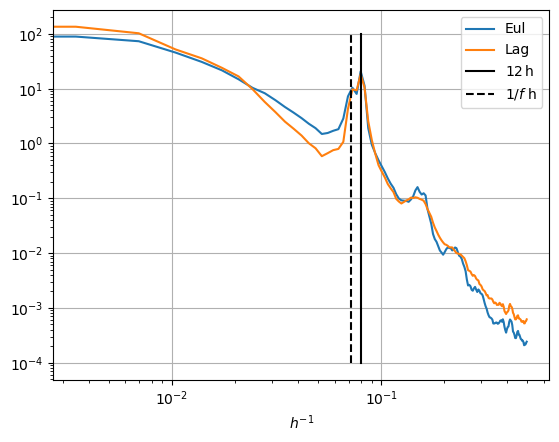

In [101]:
plt.loglog(freq_eul,np.nanmean(KE_eul,axis=(1,2)),label='Eul')
plt.loglog(freq_lag,np.nanmean(KE_lag,axis=(1)),label='Lag')
plt.loglog([1/12.5,1/12.5],[1e-4,1e2],label=r'$12 \, \mathrm{h}$',color='k',linestyle='-')
plt.loglog([np.nanmean(f_freq)/2/np.pi,np.nanmean(f_freq)/2/np.pi],[1e-4,1e2],label=r'$1/f \; \mathrm{h}$',color='k',linestyle='--')

plt.grid(True)
plt.xlabel(r'$h^{-1}$')
plt.legend(loc=1)

# check HF Eul and Lag 500m

In [119]:
data_dir='/meddy/simingzhang/Data/iceland_500m/'
fname='iceland_wave/z_niskin_500m_his_depth.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
files=data_dir+fname
print(files)
ds=xr.open_dataset(files)
ds

grid=xr.open_dataset(data_dir+'sample_niskin_500m_grd.nc')
dx=1/grid['pm'].values
dy=1/grid['pn'].values
latr=grid['lat_rho'].values

xscale=np.mean([dx,dy])
# R=xscale*287
u_eul=u2rho_3d(np.squeeze(ds['u'].values))
v_eul=v2rho_3d(np.squeeze(ds['v'].values))
time1=0
time2=20*24
KE_eul,freq_eul=spectral_freq(u_eul[time1:time2,:,:],v_eul[time1:time2,:,:],detr=1,wind=1)
# KE_eul, freq_eul = spectral_freq_parallel(u, v, detr=1, wind=1, n_jobs=4)


/meddy/simingzhang/Data/iceland_500m/iceland_wave/z_niskin_500m_his_depth.0002.nc


In [120]:
data_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_rough_500m/'
pname='wave_pars_P1089T89.5days.nc'
ds=xr.open_dataset(f'{data_dir}{pname}')
ue=ds['ue'].values
ve=ds['ve'].values
ue1=filter_particles(ue,time1,time2)
ve1=filter_particles(ve,time1,time2)
KE_lag,freq_lag=spectral_freq_lag(ue1.T,ve1.T,detr=1,wind=1)

In [121]:
u_eul.shape

(2147, 866, 866)

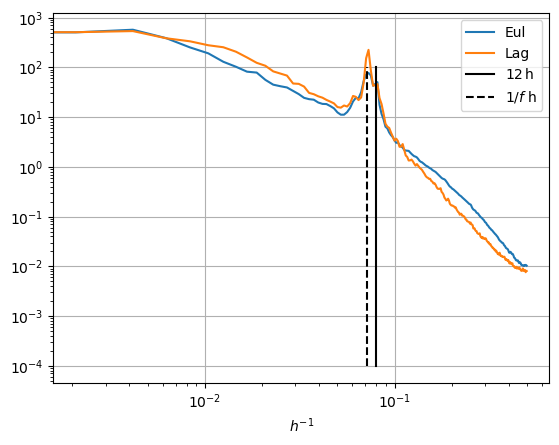

In [122]:
plt.loglog(freq_eul,np.nanmean(KE_eul,axis=(1,2)),label='Eul')
plt.loglog(freq_lag,np.nanmean(KE_lag,axis=(1)),label='Lag')
plt.loglog([1/12.5,1/12.5],[1e-4,1e2],label=r'$12 \, \mathrm{h}$',color='k',linestyle='-')
plt.loglog([np.nanmean(f_freq)/2/np.pi,np.nanmean(f_freq)/2/np.pi],[1e-4,1e2],label=r'$1/f \; \mathrm{h}$',color='k',linestyle='--')

plt.grid(True)
plt.xlabel(r'$h^{-1}$')
plt.legend(loc=1)